In [1]:
# Week 2 - Training Loops & Autograd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

print("✅ PyTorch ready!")
print("Version:", torch.__version__)

✅ PyTorch ready!
Version: 2.11.0+cpu


In [2]:
# Fake data: House size (in hundreds of sqft) -> Price (in millions KES)
# X = input, y = correct answer
X = torch.tensor([[1.0], [2.0], [3.0], [4.0], [5.0]])
y = torch.tensor([[2.0], [4.0], [6.0], [8.0], [10.0]])

print("Input (House sizes):", X)
print("Target prices:", y)

Input (House sizes): tensor([[1.],
        [2.],
        [3.],
        [4.],
        [5.]])
Target prices: tensor([[ 2.],
        [ 4.],
        [ 6.],
        [ 8.],
        [10.]])


In [3]:
# Random starting weights - the model knows NOTHING yet
weight = torch.randn(1, 1, requires_grad=True)
bias = torch.randn(1, requires_grad=True)

print("Starting random weight:", weight.item())
print("Starting random bias:", bias.item())

Starting random weight: -0.18800948560237885
Starting random bias: 0.34327051043510437


In [4]:
def predict(X):
    return X @ weight + bias   # Simple linear: y = weight * X + bias

# Test current (bad) prediction
predictions = predict(X)
print("Model predictions:", predictions)

# Loss function - how wrong is the model?
def mse_loss(pred, target):
    return ((pred - target) ** 2).mean()

loss = mse_loss(predictions, y)
print("Current Loss (how bad):", loss.item())

Model predictions: tensor([[ 0.1553],
        [-0.0327],
        [-0.2208],
        [-0.4088],
        [-0.5968]], grad_fn=<AddBackward0>)
Current Loss (how bad): 48.27260208129883


In [5]:
learning_rate = 0.01
losses = []

for epoch in range(300):          # Train for 300 rounds
    # 1. Forward pass - make prediction
    predictions = predict(X)

    # 2. Calculate loss
    loss = mse_loss(predictions, y)
    losses.append(loss.item())

    # 3. Backward pass - calculate gradients
    loss.backward()

    # 4. Update parameters (manually)
    with torch.no_grad():
        weight -= learning_rate * weight.grad
        bias -= learning_rate * bias.grad

    # 5. Zero gradients (very important!)
    weight.grad.zero_()
    bias.grad.zero_()

    if epoch % 50 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.4f}")

Epoch 0: Loss = 48.2726
Epoch 50: Loss = 0.1008
Epoch 100: Loss = 0.0719
Epoch 150: Loss = 0.0512
Epoch 200: Loss = 0.0365
Epoch 250: Loss = 0.0260


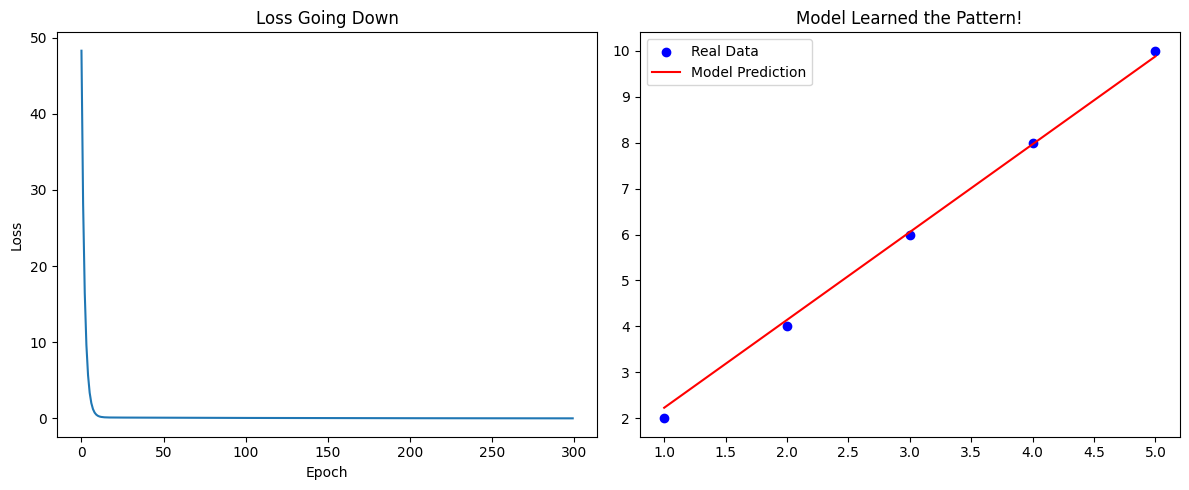

In [6]:
plt.figure(figsize=(12, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title('Loss Going Down')
plt.xlabel('Epoch')
plt.ylabel('Loss')

# Final prediction
plt.subplot(1, 2, 2)
with torch.no_grad():
    final_pred = predict(X)

plt.scatter(X.numpy(), y.numpy(), color='blue', label='Real Data')
plt.plot(X.numpy(), final_pred.numpy(), color='red', label='Model Prediction')
plt.title('Model Learned the Pattern!')
plt.legend()

plt.tight_layout()
plt.show()